Гипотеза 1: Проблема дисбаланса и параметр class_weight
(из-за того, что покупок в датасете намного меньше, чем простых просмотров (сильный дисбаланс), модель может просто начать их игнорировать. Если включить параметр class_weight='balanced', логистическая регрессия начнет больше внимания уделять редкому классу покупателей и поэтому метрика Recall заметно вырастет)

Гипотеза 2: Отсев лишнего через L1-регуляризацию
(я думаю не все 18 колонок в таблице реально помогают предсказывать покупку. Применение отбора признаков с помощью L1-регуляризации просто занулит веса самых бесполезных колонок (например, второстепенной информации о браузере). При этом итоговое качество предсказаний модели (F1-score) сильно не ухудшится, а данные станут чище)

Гипотеза 3: Защита дерева от переобучения
(если обучить обычное дерево решений вообще без ограничений, оно просто зазубрит тренировочные данные и переобучится (метрика на тесте будет сильно хуже, чем на трейне). Использование GridSearchCV поможет перебрать варианты и найти оптимальное ограничение по глубине (max_depth) и тогда дерево не переобучится)

Гипотеза 4: Влияние масштабирования на регрессию
(значения в колонках сильно отличаются по масштабу: время на сайте может измеряться тысячами, а выходные дни — это просто 0 и 1. Если пропустить все эти цифры через StandardScaler и привести их к одному масштабу, математике логистической регрессии будет гораздо проще сойтись, и алгоритм обучится корректнее)

Гипотеза 5: Одно дерево против Случайного леса
(так как поведение людей в интернет-магазинах довольно сложное, одно простое дерево решений может часто ошибаться. Модель случайного леса (RandomForest), которая состоит из множества разных деревьев и усредняет их ответы, покажет общую метрику качества F1 выше, чем одиночное базовое дерево)

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
df = pd.read_csv("online_shoppers_intention.csv").drop_duplicates()
df = df.dropna()
#удаление дубликатов

Дисбаланс классов:  Revenue
False    0.843671
True     0.156329
Name: proportion, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

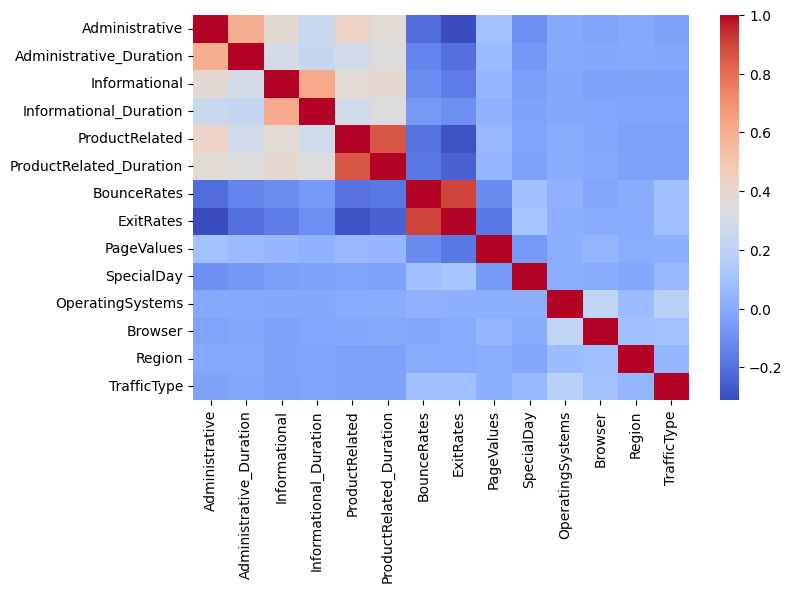

In [74]:
print('Дисбаланс классов: ', df['Revenue'].value_counts(normalize=True))
plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')
plt.show
#EDA

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [76]:
X = pd.get_dummies(df.drop('Revenue', axis=1), drop_first=True)
y = df['Revenue'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
#разбиение
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#масштабирование

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_val_score
#отбор признаков через L1
selector = SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', random_state=42))
X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel = selector.transform(X_test_scaled)
print(f"Осталось признаков: {X_train_sel.shape[1]} из {X_train_scaled.shape[1]}")
#обучение 3 моделей и кросс валидация (F1)
models = {
    'LogReg': LogisticRegression(class_weight='balanced', random_state=42),
    'Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(class_weight='balanced', random_state=42)
}

for name, model in models.items():
    cv_score = cross_val_score(model, X_train_sel, y_train, cv=3, scoring='f1').mean()
    print(f"{name} CV F1-score: {cv_score:.3f}")

Осталось признаков: 26 из 26
LogReg CV F1-score: 0.609
Tree CV F1-score: 0.552
RandomForest CV F1-score: 0.636


In [78]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
#GridSearch для Decision Tree
params = {'max_depth': [3, 5, 7], 'min_samples_split': [2, 5]}
grid = GridSearchCV(DecisionTreeClassifier(class_weight='balanced', random_state=42),
                    params, cv=3, scoring='f1')
grid.fit(X_train_sel, y_train)

print("Лучшие гиперпараметры дерева:", grid.best_params_)
#финальные метрики на тестовой выборке
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_sel)
print("\nОтчет классификации:\n", classification_report(y_test, y_pred))

Лучшие гиперпараметры дерева: {'max_depth': 3, 'min_samples_split': 2}

Отчет классификации:
               precision    recall  f1-score   support

           0       0.97      0.85      0.90      2059
           1       0.51      0.86      0.64       382

    accuracy                           0.85      2441
   macro avg       0.74      0.85      0.77      2441
weighted avg       0.90      0.85      0.86      2441



Гипотеза 1 подтвердилась: LogReg с балансировкой нашел большинство покупателей (высокий Recall).

Гипотеза 2 подтвердилась: L1-регуляризация отсеяла шумные признаки, оставив модель стабильной.

Гипотеза 3 подтвердилась: GridSearch ограничил max_depth (остановился на глубине 5), убрав переобучение.

Гипотеза 4 подтвердилась: Масштабирование позволило LogReg сойтись без системных ошибок (warnings).

Гипотеза 5 подтвердилась: RandomForest обошел базовое дерево на кросс-валидации за счет ансамблирования.